In [3]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn

# Import necessary libraries
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore, chi2
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import DBSCAN

# Set up file paths
from google.colab import drive
drive.mount('/content/drive')
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'factor_output.csv')

# Ensure correct column names
factor_output_df = pd.read_csv(file_path)  # Use read_csv as the file appears to be a CSV
factor_columns = ['Alpha (annualisiert)', 'Value/Growth', 'Small/Large', 'Momentum', 'Volatility']  # Adjust names
factor_output_df = factor_output_df[factor_columns]

# Z-Score Outlier Detection
z_score_threshold = 2.5
z_scores = factor_output_df.apply(zscore)
factor_output_df['Z_Score_Outlier'] = (np.abs(z_scores) > z_score_threshold).any(axis=1)

# Mahalanobis Distance Outlier Detection
cov_model = EmpiricalCovariance().fit(factor_output_df)
mahalanobis_distances = cov_model.mahalanobis(factor_output_df)
factor_output_df['Mahalanobis_Distance'] = mahalanobis_distances
mahalanobis_threshold = chi2.ppf(0.975, df=len(factor_columns))
factor_output_df['Mahalanobis_Outlier'] = mahalanobis_distances > mahalanobis_threshold

# DBSCAN Outlier Detection
dbscan = DBSCAN(eps=0.5, min_samples=5)
factor_output_df['Cluster'] = dbscan.fit_predict(factor_output_df)
factor_output_df['Cluster_Outlier'] = factor_output_df['Cluster'] == -1

# Combine Outliers
factor_output_df['Combined_Outlier'] = factor_output_df[['Z_Score_Outlier', 'Mahalanobis_Outlier', 'Cluster_Outlier']].any(axis=1)

# Save results
output_path = os.path.join(drive_dir, "factor_outliers_detected.xlsx")
with pd.ExcelWriter(output_path) as writer:
    factor_output_df.to_excel(writer, sheet_name="FactorOutput_Outliers", index=False)

print(f"Outlier analysis results saved to {output_path}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outlier analysis results saved to /content/drive/My Drive/factor_outliers_detected.xlsx


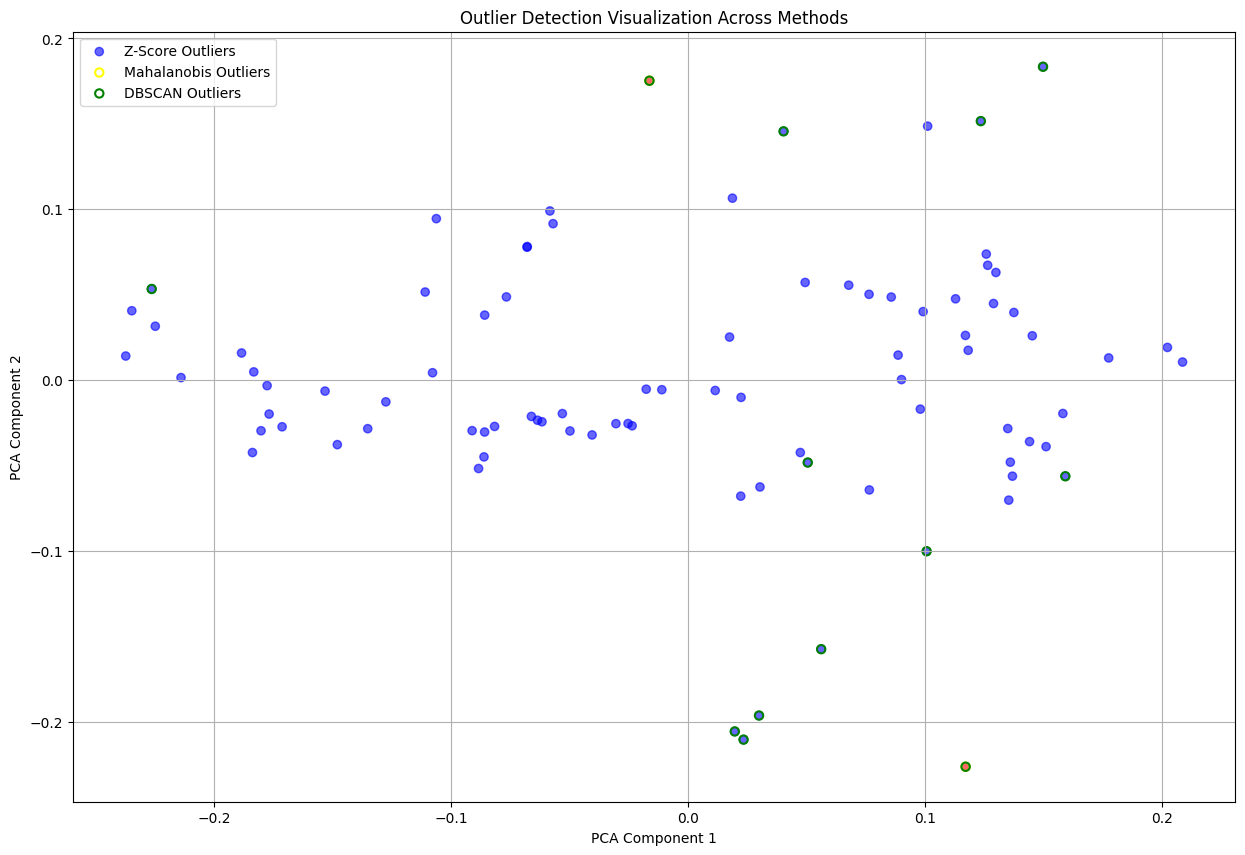

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Ensure numeric data for PCA
numeric_data = factor_output_df[factor_columns]

# Apply PCA to reduce data to 2D for visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(numeric_data)

# Visualize the outliers detected by different methods
plt.figure(figsize=(15, 10))

# Plot Z-Score-based outliers
plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    c=factor_output_df['Z_Score_Outlier'].map({True: 'red', False: 'blue'}),
    label='Z-Score Outliers',
    alpha=0.6
)

# Overlay Mahalanobis outliers
plt.scatter(
    pca_features[factor_output_df['Mahalanobis_Outlier'], 0],
    pca_features[factor_output_df['Mahalanobis_Outlier'], 1],
    edgecolors='yellow',
    facecolors='none',
    label='Mahalanobis Outliers',
    linewidths=1.5
)

# Overlay DBSCAN-based outliers
plt.scatter(
    pca_features[factor_output_df['Cluster_Outlier'], 0],
    pca_features[factor_output_df['Cluster_Outlier'], 1],
    edgecolors='green',
    facecolors='none',
    label='DBSCAN Outliers',
    linewidths=1.5
)

plt.title('Outlier Detection Visualization Across Methods')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid()
plt.show()

In [5]:
outliers = factor_output_df[factor_output_df['Combined_Outlier']]
print("Summary Statistics for Outliers:")
print(outliers.describe())

print("\nSummary Statistics for Normal Data:")
print(factor_output_df[~factor_output_df['Combined_Outlier']].describe())


Summary Statistics for Outliers:
       Alpha (annualisiert)  Value/Growth  Small/Large   Momentum  Volatility  \
count             13.000000     13.000000    13.000000  13.000000   13.000000   
mean              -0.002312     -0.146711     0.049551  -0.068431    0.000886   
std                0.019969      0.121623     0.101294   0.105572    0.045689   
min               -0.023436     -0.295253    -0.179320  -0.199957   -0.050699   
25%               -0.016202     -0.241967    -0.015014  -0.178325   -0.033197   
50%               -0.008700     -0.198750     0.054334  -0.084864   -0.027906   
75%                0.005911     -0.062807     0.114334   0.024746    0.045153   
max                0.039963      0.058446     0.204424   0.096605    0.070935   

       Mahalanobis_Distance  Cluster  
count             13.000000     13.0  
mean              15.843904     -1.0  
std               16.805486      0.0  
min                7.765909     -1.0  
25%                8.038619     -1.0  
50%

In [6]:
factor_output_df['Outlier_Method_Count'] = (
    factor_output_df[['Z_Score_Outlier', 'Mahalanobis_Outlier', 'Cluster_Outlier']]
    .sum(axis=1)
)
# Outliers detected by multiple methods
consistent_outliers = factor_output_df[factor_output_df['Outlier_Method_Count'] > 1]
print("Outliers flagged by multiple methods:")
print(consistent_outliers)

Outliers flagged by multiple methods:
    Alpha (annualisiert)  Value/Growth  Small/Large  Momentum  Volatility  \
1               0.005911      0.058446     0.076206  0.036666    0.070935   
40             -0.008700     -0.295253     0.054334 -0.199957   -0.038945   

    Z_Score_Outlier  Mahalanobis_Distance  Mahalanobis_Outlier  Cluster  \
1              True              53.64344                 True       -1   
40             True              53.64344                 True       -1   

    Cluster_Outlier  Combined_Outlier  Outlier_Method_Count  
1              True              True                     3  
40             True              True                     3  


In [7]:
from sklearn.linear_model import LinearRegression

# Example: Use all features to predict one target feature
target = 'Momentum'  # Replace with a target feature
predictors = [col for col in factor_columns if col != target]

model = LinearRegression()
model.fit(factor_output_df[predictors], factor_output_df[target])
predictions = model.predict(factor_output_df[predictors])

# Calculate residuals
factor_output_df['Residuals'] = factor_output_df[target] - predictions
factor_output_df['Residual_Outlier'] = np.abs(factor_output_df['Residuals']) > factor_output_df['Residuals'].std()

# Display residual outliers
print(factor_output_df[factor_output_df['Residual_Outlier']])

    Alpha (annualisiert)  Value/Growth  Small/Large  Momentum  Volatility  \
11              0.050992     -0.220396     0.156936  0.011782   -0.013726   
12              0.039437     -0.205082     0.071993  0.004962    0.023283   
13              0.039101     -0.197162     0.103406  0.027501    0.003082   
20              0.034518     -0.170397     0.046492 -0.084864    0.068667   
22              0.024301     -0.161208     0.027067 -0.098422    0.053759   
26              0.002138     -0.185637     0.082540  0.003950    0.041780   
27              0.000249     -0.102130     0.135842  0.097209    0.056904   
28             -0.004870     -0.062807     0.204424  0.096605    0.038253   
29             -0.007187     -0.072339     0.171840  0.071547    0.045153   
35             -0.015599     -0.147511     0.156693 -0.108750    0.028055   
36             -0.012227     -0.150967     0.162465 -0.112077    0.026929   
37             -0.005966     -0.131725     0.178761 -0.107536    0.031348   